# Contextual Compression Index

**1. 검색 속도 및 인덱싱 효율성 향상**

* 청크 수의 감소: 원문을 잘게 쪼개어 수만 개의 청크로 만드는 대신, 문서당 하나의 요약문만 인덱싱한다면 전체 벡터의 개수($N$)가 줄어든다. 결과적으로 전체 인덱스 용량($N \times d$)이 줄어들어 메모리를 절약하게 된다.

* **메모리(RAM) 절약:** 인덱스 크기가 작아지므로 동일한 메모리 사양에서 더 많은 문서를 관리하거나, 더 저렴한 인프라 비용으로 시스템을 운영할 수 있다.

**2. 검색 노이즈 제거 (Denoising)**

* **의미적 응집도 강화:** 문서에는 질문과 상관없는 부차적인 설명이나 수식어구가 포함되어 있다. 인덱싱 단계에서 이를 제거하고 핵심 의미(Semantic core)만 남겨 저장하면, 검색 시 질문 벡터와 문서 벡터 간의 정합성이 높아져 검색 정확도가 향상된다.
* **장문 문서 처리:** 아주 긴 문서는 임베딩 모델의 토큰 제한에 걸려 정보가 소실될 수 있다. 이를 미리 요약하여 압축 인덱스에 넣으면 문서 전체의 맥락을 검색 단계에서 더 잘 반영할 수 있다.

**3. 'Multi-Vector' 전략의 활용**

* **요약문 기반 검색, 원문 기반 답변:** 압축 인덱스(`ir-compressed`)에서 질문과 가장 관련 있는 요약본을 빠르게 찾아낸 뒤, 실제 LLM에게 전달할 때는 해당 요약본과 연결된(Parent-Child 관계) 원문(`ir`)을 불러오는 구조를 취할 수 있다.
* 이를 통해 **"검색은 가볍고 정확하게, 답변은 풍부한 맥락으로"** 수행하는 하이브리드 접근이 가능하다.

**4. 검색 품질의 일관성 유지**

* 다양한 포맷(PDF, HTML, 로그 파일 등)의 데이터를 표준화된 요약 형태로 인덱싱하면, 데이터 소스의 형태에 구애받지 않고 일관된 검색 성능을 기대할 수 있다.

**요약 및 비교**

| 항목 | 원문 인덱스 검색 | 압축 인덱스 검색 (ir-compressed) |
| --- | --- | --- |
| **검색 대상** | 문서 청크 전체 | 요약문, 키워드, 혹은 핵심 추출문 |
| **주요 장점** | 정보 손실 없음 | 검색 속도 빠름, 노이즈 적음 |
| **데이터 구조** | 단순 저장 | Parent-Child 또는 요약-원문 매핑 필요 |

이러한 방식은 특히 **데이터 양이 방대하여 검색 비용이 부담되거나, 문서 하나하나의 길이가 길어 검색 정확도가 떨어질 때** 매우 유용하다.

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['COHERE_API_KEY'] = os.getenv('COHERE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [4]:
import pandas as pd

document_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

## 문서 요약 체인 & 문서 압축

In [ ]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from tqdm.auto import tqdm
import time

llm = init_chat_model('gpt-5.6-luna', temperature=0.3)
prompt = PromptTemplate.from_template('''
당신은 정보의 본질을 빠르고 정확하게 파악해내는 요약전문가입니다.
다음 지문에서 핵심 내용만을 효과적이고, 효율적으로 요약해주세요.

{text}
''')
output_parser = StrOutputParser()
summary_chain = prompt | llm | output_parser

compressed_texts = []  # 요약 결과 누적 리스트
for idx, row in tqdm(document_df.iterrows(), desc='문서 요약/압축', ncols=150):
    doc_id = row['doc_id']
    content = row['content']
    summary = summary_chain.invoke({'text': content})
    compressed_texts.append({'doc_id': doc_id, 'content': summary})  # doc_id와 요약문 저장
    time.sleep(.5)  # 호출 간 대기

compressed_df = pd.DataFrame(compressed_texts)
compressed_df

문서 요약/압축: 0it [00:00, ?it/s]

,doc_id,content
0,D1,제시된 지문이 일부만 제공되어 전체 내용을 정확히 요약하기 어렵습니다. 현재 확인되...
1,D2,"비빔밥은 조선 시대부터 전해진 대표적인 한국 음식으로, 밥에 채소와 고기 등의 고명..."
2,D3,지문이 “Somet...”에서 중단되어 있어 전체 내용을 정확히 요약하기 어렵습니다...
3,D4,"세종대왕(1397~1450)은 조선 제4대 임금으로, 훈민정음을 창제해 한글 보급에..."
4,D5,이순신 장군은 임진왜란 당시 명량 해전에서 13척의 배로 133척의 일본 함대에 맞...
5,D6,"2024년 전 지구 평균 기온은 산업화 이전보다 약 1.2℃ 상승했으며, 해수면 상..."
6,D7,"최근 인공지능 분야는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발을 ..."
7,D8,"서울 지하철은 1~9호선이 운행되며, 서울역·강남역·종로 등이 주요 환승역이다."
8,D9,"판소리는 소리꾼과 고수가 함께 공연하는 한국의 전통 음악이며, 대표 작품으로 「춘향..."
9,D10,한국 축구 대표팀은 2002 한일 월드컵 4강 진출과 2012 런던 올림픽 동메달 ...


In [ ]:
# 원문과 요약문 병합해서 비교 출력
pd.set_option('display.max_colwidth', None)  # 컬럼 너비 제한을 해제

pd.merge(
    document_df[['doc_id', 'content']],  # 원문 df
    compressed_df,  # 요약문 df
    on = 'doc_id',  # 병합 기준
    suffixes=('', '_compressed')  # 중복 컬럼명 접미사
)

,doc_id,content,content_compressed
0,D1,"제주도는 대한민국의 대표 관광지로서, 한라산 등반, 성산 일출봉 관광, 해변 활동(...","제시된 지문이 일부만 제공되어 전체 내용을 정확히 요약하기 어렵습니다. 현재 확인되는 핵심 내용은 다음과 같습니다.\n\n**제주도는 대한민국의 대표적인 관광지로, 한라산 등반·성산일출봉 관광·해변 활동 등 다양한 관광과 레저를 즐길 수 있다.**"
1,D2,"비빔밥은 조선 시대부터 전해 내려온 대표적 한국 음식으로, 밥 위에 고명(채소·고기...","비빔밥은 조선 시대부터 전해진 대표적인 한국 음식으로, 밥에 채소와 고기 등의 고명을 올려 먹는다."
2,D3,"걸스데이는 2010년 데뷔한 대한민국의 4인조 걸그룹으로, 대표곡으로는 “Somet...",지문이 “Somet...”에서 중단되어 있어 전체 내용을 정확히 요약하기 어렵습니다.完整한 지문을 보내주시면 핵심 내용만 간결하게 요약해드리겠습니다.
3,D4,세종대왕(1397~1450)은 훈민정음을 창제하여 한글을 보급한 조선의 4대 임금입...,"세종대왕(1397~1450)은 조선 제4대 임금으로, 훈민정음을 창제해 한글 보급에 기여했다."
4,D5,이순신 장군(1545~1598)은 임진왜란 당시 명량 해전에서 13척의 배로 133...,이순신 장군은 임진왜란 당시 명량 해전에서 13척의 배로 133척의 일본 함대에 맞섰다. \n※ 지문이 “133…”에서 중단되어 이후 내용은 확인할 수 없습니다.
5,D6,"2024년 전 지구 평균 기온은 산업화 이전 대비 약 1.2℃ 상승했으며, 해수면 ...","2024년 전 지구 평균 기온은 산업화 이전보다 약 1.2℃ 상승했으며, 해수면 상승 등 기후변화의 영향이 나타나고 있다. \n\n※ 지문이 생략되어 있어 제공된 내용만 요약했습니다."
6,D7,"최근 인공지능 분야에서는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발...","최근 인공지능 분야는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발을 중심으로 발전하고 있다."
7,D8,"서울 지하철은 1호선부터 9호선까지 운행되며, 주요 환승역으로는 서울역·강남역·종로...","서울 지하철은 1~9호선이 운행되며, 서울역·강남역·종로 등이 주요 환승역이다."
8,D9,"판소리는 소리꾼과 고수가 함께 공연하는 한국 전통 음악으로, 대표 작품에는 “춘향가...","판소리는 소리꾼과 고수가 함께 공연하는 한국의 전통 음악이며, 대표 작품으로 「춘향가」 등이 있다."
9,D10,"한국 축구 대표팀은 2002 한일 월드컵 4강 진출, 2012 런던 올림픽 동메달 ...",한국 축구 대표팀은 2002 한일 월드컵 4강 진출과 2012 런던 올림픽 동메달 등 국제대회에서 뛰어난 성과를 거두었다.


In [ ]:
from pinecone import Pinecone, ServerlessSpec  # Pinecone 클라이언트, 인덱스 스펙설정

pc = Pinecone()
print(pc.list_indexes().names())  # 인덱스 이름

# 인덱스명 ir
if 'ir-compressed' not in pc.list_indexes().names():
    # 없으면 인덱스 생성
    pc.create_index(  
        name = 'ir-compressed',
        dimension=1536,
        metric='cosine',  # 유사도 기준
        spec=ServerlessSpec(
            region='us-east-1',
            cloud='aws'
        )
    )
    print('ir-compressed 인덱스 생성 완료')

else:
    print('ir-compressed 인덱스 이미 존재')

['ir']
ir-compressed 인덱스 생성 완료


In [11]:
# 원문 인덱스와 압축 인덱스 PineconeVectorStore 연결
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir-compressed',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)

original_vector_store = PineconeVectorStore(
    index_name = 'ir',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)

In [12]:
# 압축 문서를 Document 변환 후에 Pinecone 업서트
# DataFrame -> Langchain Document 변환
from langchain_core.documents import Document  # Langchain 문서 객체
from tqdm.auto import tqdm
from pprint import pprint

docs_to_index = []
for idx, row in tqdm(compressed_df.iterrows()):  # compressed_df을 행 단위로 순회
    doc_id = row['doc_id']  # 문서 ID 추출
    content = row['content']  # 문서 본문 추출
    doc = Document(page_content=content, metadata={'doc_id': doc_id})  # Document 형식 저장
    docs_to_index.append(doc)  # 리스트에 추가

pprint(docs_to_index)

vector_store.add_documents(docs_to_index)

0it [00:00, ?it/s]

[Document(metadata={'doc_id': 'D1'}, page_content='제시된 지문이 일부만 제공되어 전체 내용을 정확히 요약하기 어렵습니다. 현재 확인되는 핵심 내용은 다음과 같습니다.\n\n**제주도는 대한민국의 대표적인 관광지로, 한라산 등반·성산일출봉 관광·해변 활동 등 다양한 관광과 레저를 즐길 수 있다.**'),
 Document(metadata={'doc_id': 'D2'}, page_content='비빔밥은 조선 시대부터 전해진 대표적인 한국 음식으로, 밥에 채소와 고기 등의 고명을 올려 먹는다.'),
 Document(metadata={'doc_id': 'D3'}, page_content='지문이 “Somet...”에서 중단되어 있어 전체 내용을 정확히 요약하기 어렵습니다.完整한 지문을 보내주시면 핵심 내용만 간결하게 요약해드리겠습니다.'),
 Document(metadata={'doc_id': 'D4'}, page_content='세종대왕(1397~1450)은 조선 제4대 임금으로, 훈민정음을 창제해 한글 보급에 기여했다.'),
 Document(metadata={'doc_id': 'D5'}, page_content='이순신 장군은 임진왜란 당시 명량 해전에서 13척의 배로 133척의 일본 함대에 맞섰다.  \n※ 지문이 “133…”에서 중단되어 이후 내용은 확인할 수 없습니다.'),
 Document(metadata={'doc_id': 'D6'}, page_content='2024년 전 지구 평균 기온은 산업화 이전보다 약 1.2℃ 상승했으며, 해수면 상승 등 기후변화의 영향이 나타나고 있다.  \n\n※ 지문이 생략되어 있어 제공된 내용만 요약했습니다.'),
 Document(metadata={'doc_id': 'D7'}, page_content='최근 인공지능 분야는 생성형 AI, 멀티모달 모델, 강화학습 기반 에이전트 개발을 중심으로 발전하고 있다.'),
 Document(metadata={'doc_id': 'D8'

['f06c0dab-f075-49d1-8f90-f8e7971f5de0',
 'fa98abd3-d708-4611-b8e4-59a4e4ca0a11',
 '9934152a-54bd-4e50-adbd-5fc549ffdc50',
 '30d9619a-8590-4b49-995e-629564ad8fd5',
 'd5f6428a-0701-44d7-a639-f673d4e0fde5',
 'fcbb7822-32cc-4c5f-b104-ad9f4864d43d',
 '769cb556-da5b-4e68-80ae-16c7970d53fb',
 '1ffbaf30-a44d-4321-956c-39cce90313bc',
 'e11522cd-64cc-431b-938a-245c28210ca2',
 '47302c5c-3614-4525-8dc2-ad9b39546027',
 '3e8864f6-3945-47f2-856a-7546eda61ced',
 '4e1accc9-da2c-4ec0-8662-2f9f9b0d0b60',
 'fee340f1-6fd7-4389-b9e9-37387399efae',
 'f59aa902-fc8b-46e2-82ad-75220e1ce9fb',
 'a29ee003-a568-4b70-8112-c9191eaf0080',
 '2d0e35d4-9ed4-4ddf-a2e2-ccc6374c9980',
 '3b634d17-1d4e-4237-9322-7c0d2c57b19a',
 '382c61d9-6152-4b07-a444-31bd385b967b',
 '31f4e6d0-7968-4aed-bcc7-e899c2ff5aa6',
 '25ee3d7a-abf4-491b-80cc-06ab4d71350e',
 'ed292d05-eb88-471c-a087-7500e8911f9b',
 '7a539378-3ba2-459c-ac02-7789aff38368',
 '92662661-3160-427b-95bf-1039c495082a',
 '1ffc18ee-9eed-4fd9-8a11-bae0af403a89',
 'e626f131-175c-

In [13]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir',  # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩 차원이 같아야 함)
)
import numpy as np 

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')  # ';' 기준으로 분리
    rel_dict = {}  # {doc_id: grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')  # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)  # {doc_id: grade, ...}  # grade는 int형으로 변환해 값으로써 넣어줌
    return rel_dict

# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])  # top_k 개 적중 개수
    predicted = hits / k  # 정밀도 = 맞춘 갯수 / 전체 갯수

    # Recall@k
    total_relevant = len(relevant_dict)  # 전체 관련 문서 수 
    recall = hits / total_relevant if total_relevant > 0 else 0  # 재현율 = 관련 문서 맞춘 수

    # MRR 예측치 중 첫 관련문서 순위 점수
    rr = 0   # 관련 문서 수 
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)  # 첫 적중 순위 역수
            break  # 첫 번째 적중 rr 반영 후 반복문 탈출

    # AP (MAP를 위한 사전 계산)
    num_correct = 0  # 현재까지의 적중 횟수
    precisions = []  # 적중시의 precisions
    for idx, doc in enumerate(predicted[:k]):  # top-k 범위에서
        if doc in relevant_dict:
            num_correct += 1  # 적중시 1 누적
            precisions.append(num_correct / (idx + 1))  # 현재 시점의 precisions 기록
    ap = np.mean(precisions) if precisions else 0  # precisions 평균치 사용, 없으면 0

    return precisions, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return{
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),  # 쿼리 평균 MRR
        'MAP': np.mean(ap_list)  # 쿼리 평균 MAP
    }

def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # 1. Precision@k (단일 float 값)
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])
    precision = hits / k

    # 2. Recall@k
    total_relevant = len(relevant_dict)
    recall = hits / total_relevant if total_relevant > 0 else 0

    # 3. MRR
    rr = 0
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)
            break

    # 4. AP (Average Precision)
    num_correct = 0
    prec_at_hits = []
    for idx, doc in enumerate(predicted[:k]):
        if doc in relevant_dict:
            num_correct += 1
            prec_at_hits.append(num_correct / (idx + 1))
    ap = np.mean(prec_at_hits) if prec_at_hits else 0.0

    # 주의: 첫 번째 반환값을 리스트(prec_at_hits)가 아닌 단일 float(precision)으로 반환합니다.
    return precision, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return{
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),  # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),  # 쿼리 평균 MRR
        'MAP': np.mean(ap_list)  # 쿼리 평균 MAP
    }

In [ ]:
original_results = {}  # {qid: [doc_id, ...], ...}
compressed_results = {}  # {qid: [doc_id, ...], ...}
top_k = 5

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']

    # 원본 벡터 서치
    docs_from_original = original_vector_store.similarity_search(query_text, k=top_k)
    original_results[qid] = [doc.metadata['doc_id'] for doc in docs_from_original]

    # 압축 벡터 서치
    docs = vector_store.similarity_search(query_text, k=top_k)
    compressed_results[qid] = [doc.metadata['doc_id'] for doc in docs]

0it [00:00, ?it/s]

In [16]:
original_metrics = evaluate_all(original_results, queries_df, k=5)
compressed_metrics = evaluate_all(compressed_results, queries_df, k=5) 

In [17]:
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],  # 지표 이름
    'Original': [original_metrics['P@k'], original_metrics['R@k'], original_metrics['MRR'], original_metrics['MAP']],
    'Compressed': [compressed_metrics['P@k'], compressed_metrics['R@k'], compressed_metrics['MRR'], compressed_metrics['MAP']]
})
metrics_df

,Metrics,Original,Compressed
0,P@5,0.246667,0.246667
1,R@5,0.888889,0.888889
2,MRR,0.950000,0.950000
3,MAP,0.920556,0.920556


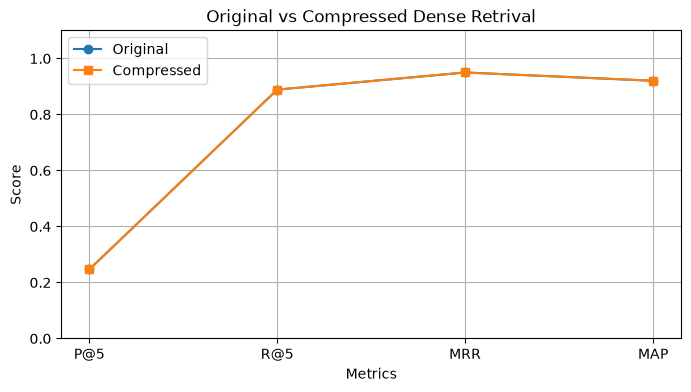

In [18]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
original_vals = [original_metrics['P@k'], original_metrics['R@k'], original_metrics['MRR'], original_metrics['MAP']]
compressed_vals = [compressed_metrics['P@k'], compressed_metrics['R@k'], compressed_metrics['MRR'], compressed_metrics['MAP']]

x = range(len(metrics))  # 0~3

plt.figure(figsize=(8, 4))
plt.plot(x, original_vals, marker='o', label='Original')
plt.plot(x, compressed_vals, marker='s', label='Compressed')
plt.xticks(x, metrics)  # x축 눈금은 0~3 -> 지표명
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Original vs Compressed Dense Retrival')
plt.legend()
plt.grid()
plt.show()